In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Hyperparameters
BATCH_SIZE = 64
LR = 1e-4
N_EPOCHS = 1000
SIGMA_BEGIN = 1.0
SIGMA_END = 0.01
NUM_CLASSES = 10

Using device: cuda


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

dataset = datasets.CIFAR10(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

dataloader = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

100%|██████████| 170M/170M [00:03<00:00, 47.8MB/s] 


In [4]:
def show_images(images, title=""):
    images = images.detach().cpu()
    images = images / 2 + 0.5
    images = np.clip(images, 0, 1)

    grid_size = int(np.ceil(np.sqrt(images.shape[0])))
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(8, 8))

    for i, ax in enumerate(axes.flat):
        if i < len(images):
            ax.imshow(images[i].permute(1, 2, 0))
        ax.axis('off')

    plt.suptitle(title)
    plt.show()

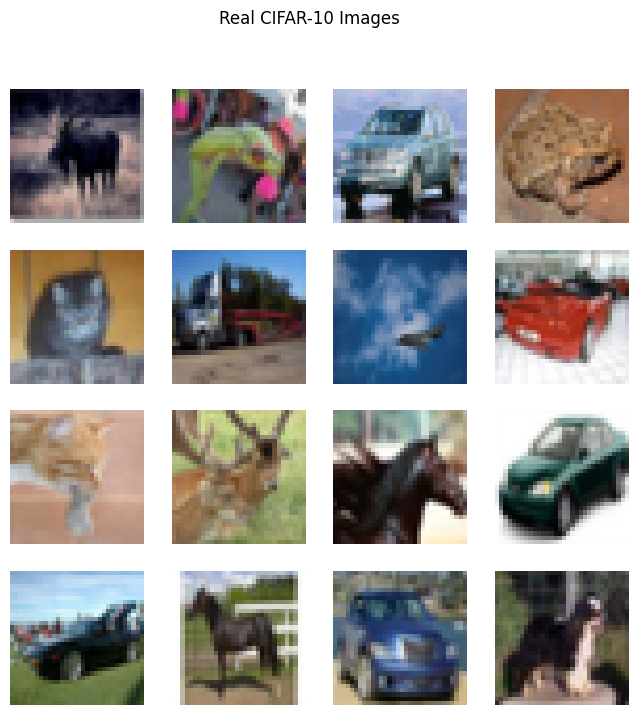

In [5]:
real_batch, _ = next(iter(dataloader))
show_images(real_batch[:16], "Real CIFAR-10 Images")

In [6]:
class GaussianFourierProjection(nn.Module):

    def __init__(self, embed_dim, scale=30.):
        super().__init__()
        self.W = nn.Parameter(
            torch.randn(embed_dim // 2) * scale,
            requires_grad=False
        )

    def forward(self, x):
        x_proj = x[:, None] * self.W[None, :] * 2 * np.pi
        return torch.cat([
            torch.sin(x_proj),
            torch.cos(x_proj)
        ], dim=-1)

In [7]:
class Dense(nn.Module):

    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.dense = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        return self.dense(x)[..., None, None]

In [8]:
class ScoreNet(nn.Module):

    def __init__(self, channels=[32, 64, 128, 256], embed_dim=256):
        super().__init__()

        self.embed = GaussianFourierProjection(embed_dim)

        self.conv1 = nn.Conv2d(3, channels[0], 3, 1, 1)
        self.dense1 = Dense(embed_dim, channels[0])
        self.gn1 = nn.GroupNorm(4, channels[0])

        self.conv2 = nn.Conv2d(channels[0], channels[1], 3, 2, 1)
        self.dense2 = Dense(embed_dim, channels[1])
        self.gn2 = nn.GroupNorm(32, channels[1])

        self.conv3 = nn.Conv2d(channels[1], channels[2], 3, 2, 1)
        self.dense3 = Dense(embed_dim, channels[2])
        self.gn3 = nn.GroupNorm(32, channels[2])

        self.tconv2 = nn.ConvTranspose2d(
            channels[2], channels[1], 3, 2, 1, output_padding=1
        )
        self.dense4 = Dense(embed_dim, channels[1])
        self.gn4 = nn.GroupNorm(32, channels[1])

        self.tconv1 = nn.ConvTranspose2d(
            channels[1]*2, channels[0], 3, 2, 1, output_padding=1
        )
        self.dense5 = Dense(embed_dim, channels[0])
        self.gn5 = nn.GroupNorm(32, channels[0])

        self.final = nn.Conv2d(channels[0]*2, 3, 3, 1, 1)

        self.act = nn.SiLU()

    def forward(self, x, sigma_idx, sigma_labels):

        embed = self.act(self.embed(sigma_labels))

        h1 = self.conv1(x)
        h1 += self.dense1(embed)
        h1 = self.act(self.gn1(h1))

        h2 = self.conv2(h1)
        h2 += self.dense2(embed)
        h2 = self.act(self.gn2(h2))

        h3 = self.conv3(h2)
        h3 += self.dense3(embed)
        h3 = self.act(self.gn3(h3))

        h2_dec = self.tconv2(h3)
        h2_dec += self.dense4(embed)
        h2_dec = self.act(self.gn4(h2_dec))

        h2_cat = torch.cat([h2_dec, h2], dim=1)

        h1_dec = self.tconv1(h2_cat)
        h1_dec += self.dense5(embed)
        h1_dec = self.act(self.gn5(h1_dec))

        h1_cat = torch.cat([h1_dec, h1], dim=1)

        out = self.final(h1_cat)

        return out / sigma_labels[:, None, None, None]

In [9]:
model = ScoreNet().to(DEVICE)

optimizer = optim.Adam(
    model.parameters(),
    lr=LR
)

print("Model Initialized")

Model Initialized


In [10]:
sigmas = torch.exp(
    torch.linspace(
        np.log(SIGMA_BEGIN),
        np.log(SIGMA_END),
        NUM_CLASSES
    )
).to(DEVICE)

In [11]:
def loss_fn(model, x):

    batch_size = x.shape[0]

    labels = torch.randint(
        0,
        len(sigmas),
        (batch_size,),
        device=DEVICE
    )

    used_sigmas = sigmas[labels].view(batch_size,1,1,1)

    noise = torch.randn_like(x)
    perturbed_x = x + noise * used_sigmas

    target_score = -noise / used_sigmas

    predicted_score = model(
        perturbed_x,
        labels,
        used_sigmas[:,0,0,0]
    )

    loss = torch.sum(
        (predicted_score - target_score)**2 *
        (used_sigmas**2)
    ) / batch_size

    return loss

In [ ]:
from tqdm import tqdm

model.train()
losses = []

print("Starting Training...")

for epoch in range(N_EPOCHS):

    epoch_loss = 0

    # progress bar for batches
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}", leave=False)

    for x, _ in pbar:

        x = x.to(DEVICE)

        optimizer.zero_grad()

        loss = loss_fn(model, x)

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        # show live batch loss
        pbar.set_postfix({
            "batch_loss": f"{loss.item():.4f}"
        })

    avg_loss = epoch_loss / len(dataloader)
    losses.append(avg_loss)

    print(f"Epoch {epoch+1}/{N_EPOCHS} | Avg Loss: {avg_loss:.4f}")

Starting Training...


Epoch 1/1000 | Avg Loss: 1547.4103


Epoch 2/1000 | Avg Loss: 1130.5996


Epoch 3/1000 | Avg Loss: 1073.6846


Epoch 4/1000 | Avg Loss: 1045.1434


...

Epoch 885/1000 | Avg Loss: 820.6166


Epoch 886/1000 | Avg Loss: 816.4304


Epoch 887/1000 | Avg Loss: 815.8031


Epoch 888/1000 | Avg Loss: 815.2670


Epoch 889/1000:  36%|███▌      | 283/782 [00:03<00:05, 84.12it/s, batch_loss=745.8275] 

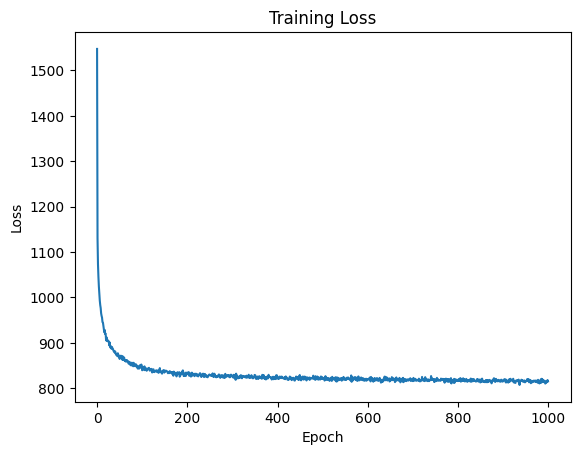

In [16]:
plt.plot(losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [17]:
def annealed_langevin_dynamics(
        model,
        sigmas,
        n_samples=16,
        step_lr=0.00002,
        T=100):

    model.eval()

    x = torch.rand(n_samples,3,32,32).to(DEVICE)

    with torch.no_grad():

        for i, sigma in enumerate(tqdm(sigmas)):

            sigma_val = sigma.item()

            labels = torch.ones(
                n_samples,
                device=DEVICE
            ).long() * i

            alpha = step_lr * (
                sigma_val / sigmas[-1].item()
            ) ** 2

            for t in range(T):

                z = torch.randn_like(x)

                score = model(
                    x,
                    labels,
                    sigma.repeat(n_samples)
                )

                x = x + (alpha/2)*score + np.sqrt(alpha)*z

    return x

Generating Samples...


100%|██████████| 10/10 [00:01<00:00,  6.70it/s]


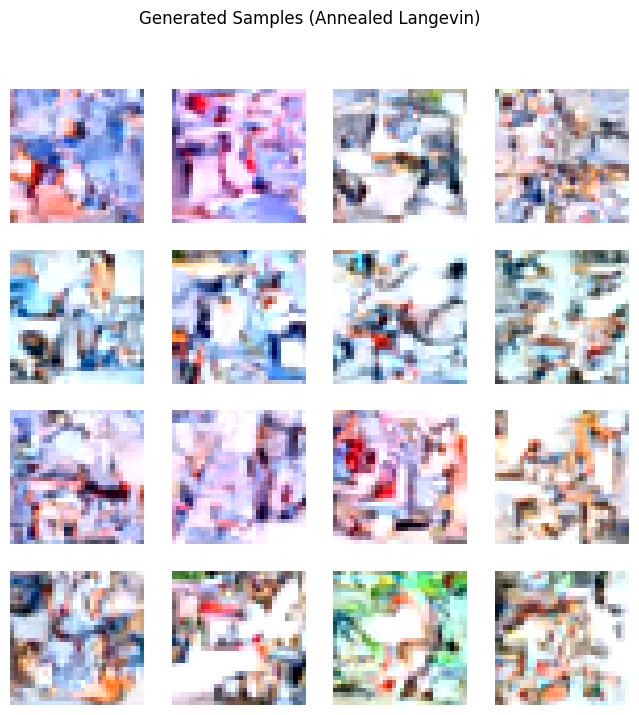

In [18]:
STEP_LR = 0.00001
STEPS_PER_SIGMA = 100

print("Generating Samples...")

generated_images = annealed_langevin_dynamics(
    model,
    sigmas,
    n_samples=16,
    step_lr=STEP_LR,
    T=STEPS_PER_SIGMA
)

show_images(
    generated_images,
    "Generated Samples (Annealed Langevin)"
)

In [19]:
import torch

# Save model weights
torch.save(model.state_dict(), "model_weights.pth")

print("Model weights saved!")

Model weights saved!
